# Federated Learning with CIC-IoT-2023 Dataset - Attack & Defense Implementation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_DIRECTORY = '/content/drive/MyDrive/Colab Notebooks/data/CICIoT2023/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install flwr[simulation] torch torchvision matplotlib scikit-learn openml

In [3]:
import os
import pandas as pd
import numpy as np
import flwr as fl
from tqdm import tqdm
import warnings
from typing import List, Tuple, Optional, Dict, Union
from scipy.spatial.distance import cosine

import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from flwr.common import Metrics, Parameters, Scalar
from flwr.client import NumPyClient
from torch.utils.data import DataLoader, random_split, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import sys
# Add the folder containing defense_system.py to Python's search path
sys.path.append('/content/drive/MyDrive/Colab Notebooks')
# Import defense system
from defense_system import FLTrustDefense, KrumDefense, create_defense, get_defense_config

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
print("flwr", fl.__version__)
print("numpy", np.__version__)
print("torch", torch.__version__)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training on {DEVICE}")

flwr 1.22.0
numpy 2.0.2
torch 2.8.0+cu126
Training on cpu


## Configuration Settings

In [23]:
SPLIT_AVAILABLE_METHODS = ['STRATIFIED','LEAVE_ONE_OUT', 'ONE_CLASS', 'HALF_BENIGN' ,'DIRICHLET']
METHOD = 'DIRICHLET'
NUM_OF_ROUNDS = 5
NUM_OF_DIRICHLET_CLIENTS = 5
DIRICHLET_ALPHA = 0.5

individual_classifier = True
group_classifier = False
binary_classifier = False

# Defense Strategy Configuration
DEFENSE_STRATEGY = 'NONE'  # Options: 'NONE', 'KRUM', 'FLTRUST'
FLTRUST_BETA = 0.5
SERVER_DATA_RATIO = 0.1
KRUM_M = 2

ATTACK_TYPE = 'MIMIC_ATTACK'  # Options: 'MODEL_POISONING', 'GRADIENT_ASCENT', 'BYZANTINE_ATTACK', 'MIMIC_ATTACK'
num_malicious_clients = 3

print(f"Selected defense strategy: {DEFENSE_STRATEGY}")

Selected defense strategy: NONE


In [24]:
# Initialize defense instance
defense_instance = create_defense(DEFENSE_STRATEGY, **get_defense_config(DEFENSE_STRATEGY))
print(f"Defense instance: {type(defense_instance).__name__ if defense_instance else 'None'}")

Defense instance: None


## Data Setup

In [25]:
# Load dataset
df_sets = [k for k in os.listdir(DATASET_DIRECTORY) if k.endswith('.csv')]
df_sets.sort()
training_sets = df_sets[:int(len(df_sets)*.8)]

# Label mappings
dict_34_classes = {
    'BENIGN': 0, 'DDOS-RSTFINFLOOD': 1, 'DDOS-PSHACK_FLOOD': 2, 'DDOS-SYN_FLOOD': 3,
    'DDOS-UDP_FLOOD': 4, 'DDOS-TCP_FLOOD': 5, 'DDOS-ICMP_FLOOD': 6, 'DDOS-SYNONYMOUSIP_FLOOD': 7,
    'DDOS-ACK_FRAGMENTATION': 8, 'DDOS-UDP_FRAGMENTATION': 9, 'DDOS-ICMP_FRAGMENTATION': 10,
    'DDOS-SLOWLORIS': 11, 'DDOS-HTTP_FLOOD': 12, 'DOS-UDP_FLOOD': 13, 'DOS-SYN_FLOOD': 14,
    'DOS-TCP_FLOOD': 15, 'DOS-HTTP_FLOOD': 16, 'MIRAI-GREETH_FLOOD': 17, 'MIRAI-GREIP_FLOOD': 18,
    'MIRAI-UDPPLAIN': 19, 'RECON-PINGSWEEP': 20, 'RECON-OSSCAN': 21, 'RECON-PORTSCAN': 22,
    'VULNERABILITYSCAN': 23, 'RECON-HOSTDISCOVERY': 24, 'DNS_SPOOFING': 25, 'MITM-ARPSPOOFING': 26,
    'BROWSERHIJACKING': 27, 'BACKDOOR_MALWARE': 28, 'XSS': 29, 'UPLOADING_ATTACK': 30,
    'SQLINJECTION': 31, 'COMMANDINJECTION': 32, 'DICTIONARYBRUTEFORCE': 33
}

# Load and process data
if os.path.isfile('training_data.pkl'):
    train_df = pd.read_pickle('training_data.pkl')
else:
    combined_df = pd.DataFrame()
    for file in tqdm(training_sets):
        df_temp = pd.read_csv(DATASET_DIRECTORY + file)
        combined_df = pd.concat([combined_df, df_temp], ignore_index=True)

    combined_df['Label'] = combined_df['Label'].map(dict_34_classes)
    combined_df = combined_df.dropna(subset=['Label'])
    combined_df['Label'] = combined_df['Label'].astype(int)

    X_columns = [col for col in combined_df.columns if col != 'Label']
    y_column = 'Label'

    X_train, _, y_train, _ = train_test_split(
        combined_df[X_columns], combined_df[y_column],
        test_size=0.01, random_state=42, stratify=combined_df[y_column]
    )

    train_df = pd.concat([X_train, y_train], axis=1)
    train_df.to_pickle('training_data.pkl')

X_columns = [col for col in train_df.columns if col != 'Label']
y_column = 'Label'
class_size = "34"

print(f"Training data size: {train_df.shape}")

Training data size: (2136603, 40)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
# Data scaling
scaler = StandardScaler()
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
train_df.dropna(inplace=True)
train_df[X_columns] = scaler.fit_transform(train_df[X_columns])

# Prepare FLTrust server data
if DEFENSE_STRATEGY == 'FLTRUST' and defense_instance:
    server_data = defense_instance.prepare_server_data(train_df, X_columns, y_column)
    print(f"FLTrust server data prepared: {len(server_data)} samples")

print("Data scaling completed")

Data scaling completed


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Federated Learning Setup

In [27]:
# Data distribution
fl_X_train = []
fl_y_train = []

num_clients = NUM_OF_DIRICHLET_CLIENTS
alpha = DIRICHLET_ALPHA

y_data = train_df[y_column].values
class_indices = {}
for cls in np.unique(y_data):
    class_indices[cls] = np.where(y_data == cls)[0]

client_indices = [[] for _ in range(num_clients)]
for cls, indices in class_indices.items():
    n_samples = len(indices)
    proportions = np.random.dirichlet([alpha] * num_clients)
    splits = (proportions * n_samples).astype(int)

    while splits.sum() < n_samples:
        splits[np.argmax(proportions)] += 1
    while splits.sum() > n_samples:
        splits[np.argmax(splits)] -= 1

    np.random.shuffle(indices)
    start = 0
    for client_id, split_size in enumerate(splits):
        end = start + split_size
        client_indices[client_id].extend(indices[start:end])
        start = end

for client_id in range(num_clients):
    idxs = client_indices[client_id]
    client_df = train_df.iloc[idxs]
    fl_X_train.append(client_df[X_columns])
    fl_y_train.append(client_df[y_column])

NUM_OF_CLIENTS = len(fl_X_train)
print(f"Created {NUM_OF_CLIENTS} clients")

Created 5 clients


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
# Enhanced Attack Configuration
malicious_client_ids = [str(i) for i in range(num_malicious_clients)]

# Enhanced attack implementations
def apply_model_poisoning(model_params, poison_factor=20.0):
    """Apply aggressive model poisoning by scaling and flipping parameters"""
    poisoned_params = []
    for i, param in enumerate(model_params):
        if i % 2 == 0:
            poisoned_param = param * poison_factor
        else:
            poisoned_param = -param * (poison_factor / 2)
        poisoned_params.append(poisoned_param)
    return poisoned_params

def apply_gradient_ascent_attack(model_params):
    """Apply gradient ascent attack by reversing gradients"""
    return [-param * 5.0 for param in model_params]

def apply_byzantine_attack(model_params):
    """Generate completely random parameters"""
    poisoned_params = []
    for param in model_params:
        random_param = np.random.normal(0, 10.0, param.shape)
        poisoned_params.append(random_param.astype(param.dtype))
    return poisoned_params

def apply_mimic_attack(model_params, target_params=None, mimic_factor=0.8):
    """Mimic benign client behavior while introducing subtle poisoning"""
    if target_params is None:
        return model_params

    poisoned_params = []
    for i, (param, target) in enumerate(zip(model_params, target_params)):
        # Blend with target parameters and add aggressive noise
        mimicked = mimic_factor * target + (1 - mimic_factor) * param
        noise = np.random.normal(0, 1.0, param.shape)  # Increased noise
        poisoned_params.append(mimicked + noise)
    return poisoned_params

print(f"Attack: {ATTACK_TYPE}, Malicious clients: {malicious_client_ids}")
print(f"Enhanced attacks ready: MODEL_POISONING (factor=20), GRADIENT_ASCENT, BYZANTINE, MIMIC")

Attack: MIMIC_ATTACK, Malicious clients: ['0', '1', '2']
Enhanced attacks ready: MODEL_POISONING (factor=20), GRADIENT_ASCENT, BYZANTINE, MIMIC


In [29]:
# Model definition
class IoTAttackNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(IoTAttackNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, num_classes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

INPUT_SIZE = len(X_columns)
NUM_CLASSES = int(class_size)
LEARNING_RATE = 0.001
EPOCHS = 5
BATCH_SIZE = 32

def get_model_parameters(model):
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def set_model_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = {k: torch.tensor(v) for k, v in params_dict}
    model.load_state_dict(state_dict, strict=True)

def train_model(model, trainloader, epochs=1):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(trainloader):
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    return model

print(f"Model: {INPUT_SIZE} -> 128 -> 64 -> 32 -> {NUM_CLASSES}")

Model: 39 -> 128 -> 64 -> 32 -> 34


In [ ]:
# Flower client
class IoTClient(NumPyClient):
    def __init__(self, client_id, X_train, y_train, is_malicious=False):
        self.client_id = client_id
        self.is_malicious = is_malicious

        self.X_train = torch.FloatTensor(X_train.values)
        self.y_train = torch.LongTensor(y_train.values)

        train_dataset = TensorDataset(self.X_train, self.y_train)
        self.trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

        self.model = IoTAttackNet(INPUT_SIZE, NUM_CLASSES).to(DEVICE)

    def get_parameters(self, config):
        return get_model_parameters(self.model)

    def set_parameters(self, parameters):
        set_model_parameters(self.model, parameters)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train_model(self.model, self.trainloader, epochs=EPOCHS)

        training_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        self.model.eval()
        with torch.no_grad():
            for data, target in self.trainloader:
                data, target = data.to(DEVICE), target.to(DEVICE)
                outputs = self.model(data)
                loss = F.cross_entropy(outputs, target)
                training_loss += loss.item() * data.size(0)
                preds = outputs.argmax(dim=1)
                correct_predictions += (preds == target).sum().item()
                total_samples += target.size(0)

        avg_loss = training_loss / total_samples if total_samples > 0 else 0.0
        accuracy = correct_predictions / total_samples if total_samples > 0 else 0.0

        model_params = get_model_parameters(self.model)
        if self.is_malicious:
            if ATTACK_TYPE == 'MODEL_POISONING':
                model_params = apply_model_poisoning(model_params)
            elif ATTACK_TYPE == 'GRADIENT_ASCENT':
                model_params = apply_gradient_ascent_attack(model_params)
            elif ATTACK_TYPE == 'BYZANTINE_ATTACK':
                model_params = apply_byzantine_attack(model_params)
            elif ATTACK_TYPE == 'MIMIC_ATTACK':
                target_params = parameters if parameters else model_params
                model_params = apply_mimic_attack(model_params, target_params)
            print(f"Client {self.client_id}: Applied {ATTACK_TYPE}")

        metrics = {
            "loss": float(avg_loss),
            "accuracy": float(accuracy),
        }

        self.model.train()
        return model_params, len(self.trainloader.dataset), metrics

    def evaluate(self, parameters, config):
        return 0.0, 1, {"accuracy": 0.0}

def client_fn(cid: str) -> IoTClient:
    client_id = int(cid)
    X_train_client = fl_X_train[client_id]
    y_train_client = fl_y_train[client_id]
    is_malicious = cid in malicious_client_ids

    return IoTClient(client_id, X_train_client, y_train_client, is_malicious)

print("Client implementation completed")

Client implementation completed


In [ ]:
# Server strategy with defense
from flwr.server.strategy import FedAvg

class DefenseStrategy(FedAvg):
    def __init__(self, defense_instance, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.defense_instance = defense_instance
        self.defense_strategy = DEFENSE_STRATEGY
        self.server_model = None

        if DEFENSE_STRATEGY == 'FLTRUST':
            self.server_model = IoTAttackNet(INPUT_SIZE, NUM_CLASSES).to(DEVICE)

    def train_server_model(self):
        if self.defense_strategy != 'FLTRUST' or not hasattr(self.defense_instance, 'server_data'):
            return None

        server_X = torch.FloatTensor(self.defense_instance.server_data[X_columns].values)
        server_y = torch.LongTensor(self.defense_instance.server_data[y_column].values)
        server_dataset = TensorDataset(server_X, server_y)
        server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True)

        train_model(self.server_model, server_loader, epochs=EPOCHS)
        return get_model_parameters(self.server_model)

    def aggregate_fit(self, server_round, results, failures):
        print(f"\nRound {server_round}: Using {self.defense_strategy} defense")

        client_updates = [fl.common.parameters_to_ndarrays(fit_res.parameters)
                         for _, fit_res in results]
        for i, update in enumerate(client_updates):
            flat_update = np.concatenate([u.flatten() for u in update]) if update else np.array([])
            if flat_update.size > 0:
                norm = np.linalg.norm(flat_update)
                print(f"  Client {i} update norm (before defense): {norm:.4f}")
            else:
                print(f"  Client {i} update norm (before defense): unavailable")

        if self.defense_strategy == 'NONE':
            aggregated_parameters, aggregated_metrics = super().aggregate_fit(server_round, results, failures)
            aggregated_array = fl.common.parameters_to_ndarrays(aggregated_parameters)
            flat_params = np.concatenate([param.flatten() for param in aggregated_array]) if aggregated_array else np.array([])
            if flat_params.size > 0:
                norm = np.linalg.norm(flat_params)
                print(f"  Aggregated update norm (after NONE defense): {norm:.4f}")
            else:
                print("  Aggregated update norm (after NONE defense): unavailable")
            return aggregated_parameters, aggregated_metrics

        defended_params = None

        if self.defense_strategy == 'FLTRUST':
            server_update = self.train_server_model()
            if server_update:
                defended_params, trust_scores = self.defense_instance.aggregate(client_updates, server_update)
                print(f"Trust scores: {trust_scores}")
            else:
                return super().aggregate_fit(server_round, results, failures)

        elif self.defense_strategy == 'KRUM':
            defended_params, selected_client = self.defense_instance.aggregate(client_updates)
            print(f"Krum selected client: {selected_client}")

        else:
            return super().aggregate_fit(server_round, results, failures)

        if defended_params is None:
            return super().aggregate_fit(server_round, results, failures)

        metrics_results = [
            (fit_res.num_examples, fit_res.metrics)
            for _, fit_res in results
            if fit_res.metrics
        ]
        aggregated_metrics = {}
        if metrics_results:
            aggregated_metrics = self.aggregate_metrics(metrics_results)

        defended_flat = np.concatenate([param.flatten() for param in defended_params]) if defended_params else np.array([])
        if defended_flat.size > 0:
            norm = np.linalg.norm(defended_flat)
            print(f"  Aggregated update norm (after {self.defense_strategy} defense): {norm:.4f}")
        else:
            print(f"  Aggregated update norm (after {self.defense_strategy} defense): unavailable")

        return fl.common.ndarrays_to_parameters(defended_params), aggregated_metrics

print("Defense strategy defined")

Defense strategy defined


In [32]:
# Initialize and run simulation
server_model = IoTAttackNet(INPUT_SIZE, NUM_CLASSES).to(DEVICE)
initial_parameters = get_model_parameters(server_model)

strategy = DefenseStrategy(
    defense_instance=defense_instance,
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=NUM_OF_CLIENTS,
    min_evaluate_clients=0,
    min_available_clients=NUM_OF_CLIENTS,
    initial_parameters=fl.common.ndarrays_to_parameters(initial_parameters),
)

print(f"Starting FL simulation with {NUM_OF_CLIENTS} clients")
print(f"Attack: {ATTACK_TYPE}, Defense: {DEFENSE_STRATEGY}")
print(f"Malicious clients: {malicious_client_ids}")

Starting FL simulation with 5 clients
Attack: MIMIC_ATTACK, Defense: NONE
Malicious clients: ['0', '1', '2']


In [15]:
# from flwr.simulation import start_simulation

# history = start_simulation(
#     client_fn=client_fn,
#     num_clients=NUM_OF_CLIENTS,
#     config=fl.server.ServerConfig(num_rounds=NUM_OF_ROUNDS),
#     strategy=strategy,
#     client_resources={"num_cpus": 1, "num_gpus": 0.0},
# )

# print("\nSimulation completed!")
# print(f"Final Results - Attack: {ATTACK_TYPE}, Defense: {DEFENSE_STRATEGY}")

# Print loss and accuracy for each round
# print("\nResults per round:")
# for i in range(NUM_OF_ROUNDS):
#     round_num = i + 1
#     if history.losses_distributed:
#         loss = history.losses_distributed[i][0]
#         print(f"Round {round_num}: Loss = {loss:.4f}")
#     if history.metrics_distributed_fit:
#         # Assuming accuracy is logged in metrics_distributed_fit
#         accuracy = history.metrics_distributed_fit[i][1].get('accuracy')
#         if accuracy is not None:
#              print(f"Round {round_num}: Accuracy = {accuracy:.4f}")

# Task
Run the simulation with and without FLTrust defense and plot the results (loss and accuracy) from both simulations on the same charts for comparison.

## Run simulation without defense

### Subtask:
Configure the simulation to use no defense (`DEFENSE_STRATEGY = 'NONE'`) and run the Flower simulation, storing the history in a variable named `history_none`.


**Reasoning**:
The first step is to change the `DEFENSE_STRATEGY` variable to 'NONE'. I will modify the code cell accordingly.



In [33]:
SPLIT_AVAILABLE_METHODS = ['STRATIFIED','LEAVE_ONE_OUT', 'ONE_CLASS', 'HALF_BENIGN' ,'DIRICHLET']
METHOD = 'DIRICHLET'
NUM_OF_ROUNDS = 5
NUM_OF_DIRICHLET_CLIENTS = 5
DIRICHLET_ALPHA = 0.5

individual_classifier = True
group_classifier = False
binary_classifier = False

# Defense Strategy Configuration
DEFENSE_STRATEGY = 'NONE'  # Options: 'NONE', 'KRUM', 'FLTRUST'
FLTRUST_BETA = 0.8
SERVER_DATA_RATIO = 0.2
KRUM_M = 2

ATTACK_TYPE = 'MIMIC_ATTACK'  # Options: 'MODEL_POISONING', 'GRADIENT_ASCENT', 'BYZANTINE_ATTACK', 'MIMIC_ATTACK'
num_malicious_clients = 3

print(f"Selected defense strategy: {DEFENSE_STRATEGY}")

Selected defense strategy: NONE


**Reasoning**:
Now that the defense strategy is set to 'NONE', I need to re-initialize the defense instance to reflect this change.



In [34]:
# Initialize defense instance
defense_instance = create_defense(DEFENSE_STRATEGY, **get_defense_config(DEFENSE_STRATEGY))
print(f"Defense instance: {type(defense_instance).__name__ if defense_instance else 'None'}")

Defense instance: None


**Reasoning**:
The defense instance has been re-initialized. The next step is to re-initialize the simulation strategy with the updated defense instance.



In [35]:
# Initialize and run simulation
server_model = IoTAttackNet(INPUT_SIZE, NUM_CLASSES).to(DEVICE)
initial_parameters = get_model_parameters(server_model)

strategy = DefenseStrategy(
    defense_instance=defense_instance,
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=NUM_OF_CLIENTS,
    min_evaluate_clients=0,
    min_available_clients=NUM_OF_CLIENTS,
    initial_parameters=fl.common.ndarrays_to_parameters(initial_parameters),
)

print(f"Starting FL simulation with {NUM_OF_CLIENTS} clients")
print(f"Attack: {ATTACK_TYPE}, Defense: {DEFENSE_STRATEGY}")
print(f"Malicious clients: {malicious_client_ids}")

Starting FL simulation with 5 clients
Attack: MIMIC_ATTACK, Defense: NONE
Malicious clients: ['0', '1', '2']


**Reasoning**:
The final step for this subtask is to run the simulation with the 'NONE' defense strategy and store the history in `history_none`. I will modify the code cell to use the correct variable name and run the simulation.



In [36]:
from flwr.simulation import start_simulation

history_none = start_simulation(
    client_fn=client_fn,
    num_clients=NUM_OF_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_OF_ROUNDS),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": 0.0},
)

print("\nSimulation completed!")
print(f"Final Results - Attack: {ATTACK_TYPE}, Defense: {DEFENSE_STRATEGY}")

# Print loss and accuracy for each round
print("\nResults per round:")
for i in range(NUM_OF_ROUNDS):
    round_num = i + 1
    if history_none.losses_distributed:
        loss = history_none.losses_distributed[i][0]
        print(f"Round {round_num}: Loss = {loss:.4f}")
    if history_none.metrics_distributed_fit:
        # Assuming accuracy is logged in metrics_distributed_fit
        accuracy = history_none.metrics_distributed_fit[i][1].get('accuracy')
        if accuracy is not None:
             print(f"Round {round_num}: Accuracy = {accuracy:.4f}")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2025-10-08 03:30:45,303	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 8.0, 'object_store_memory': 16315798732.0, 'node:172.28.0.12': 1

(ClientAppActor pid=1348076) Client 2: Applied MIMIC_ATTACK


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)


(ClientAppActor pid=1348073) Client 0: Applied MIMIC_ATTACK

Round 1: Using NONE defense
  Client 0 update norm (before defense): 67.8569
  Client 1 update norm (before defense): 42.1011
  Client 2 update norm (before defense): 130.6625
  Client 3 update norm (before defense): 129.0827
  Client 4 update norm (before defense): 129.0926
  Aggregated update norm (after NONE defense): 55.4199
(ClientAppActor pid=1348072) Client 1: Applied MIMIC_ATTACK


(ClientAppActor pid=1348072) 
(ClientAppActor pid=1348072)         
(ClientAppActor pid=1348072) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context` [repeated 5x across cluster]
(ClientAppActor pid=1348072)             This is a deprecated feature. It will be removed [repeated 5x across cluster]
(ClientAppActor pid=1348072)             entirely in future versions of Flower. [repeated 5x across cluster]
(ClientAppActor pid=1348072) /tmp/ipython-input-1538606916.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of

...


Round 4: Using NONE defense
  Client 0 update norm (before defense): 158.5469
  Client 1 update norm (before defense): 159.4773
  Client 2 update norm (before defense): 107.9354
  Client 3 update norm (before defense): 101.1653
  Client 4 update norm (before defense): 160.3712
  Aggregated update norm (after NONE defense): 108.1091
(ClientAppActor pid=1348067) Client 1: Applied MIMIC_ATTACK


(ClientAppActor pid=1348067) 
(ClientAppActor pid=1348067)         
(ClientAppActor pid=1348067) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context` [repeated 5x across cluster]
(ClientAppActor pid=1348067)             This is a deprecated feature. It will be removed [repeated 5x across cluster]
(ClientAppActor pid=1348067)             entirely in future versions of Flower. [repeated 5x across cluster]
(ClientAppActor pid=1348067) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`. [repeated 5x across cluster]
(ClientAppActor pid=1348072) 
(ClientAppActor pid=1348072)         
(ClientAppActor pid=1348076) 
(ClientAppActor pid=1348076)

(ClientAppActor pid=1348073) Client 2: Applied MIMIC_ATTACK
(ClientAppActor pid=1348076) Client 0: Applied MIMIC_ATTACK
(ClientAppActor pid=1348078) Client 1: Applied MIMIC_ATTACK


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 747.89s
INFO :      



Round 5: Using NONE defense
  Client 0 update norm (before defense): 168.9892
  Client 1 update norm (before defense): 120.8109
  Client 2 update norm (before defense): 116.4960
  Client 3 update norm (before defense): 168.4215
  Client 4 update norm (before defense): 169.6812
  Aggregated update norm (after NONE defense): 121.2413

Simulation completed!
Final Results - Attack: MIMIC_ATTACK, Defense: NONE

Results per round:


## Run simulation with fltrust defense

### Subtask:
Configure the simulation to use FLTrust defense (`DEFENSE_STRATEGY = 'FLTRUST'`) and run the Flower simulation, storing the history in a variable named `history_fltrust`.


**Reasoning**:
Update the DEFENSE_STRATEGY to 'FLTRUST' to configure the simulation for FLTrust defense.



**Reasoning**:
Re-initialize the defense instance with the updated DEFENSE_STRATEGY configuration.



**Reasoning**:
Re-initialize the server strategy with the new FLTrust defense instance and then run the simulation, storing the history in `history_fltrust`.



In [20]:
# Initialize and run simulation
server_model = IoTAttackNet(INPUT_SIZE, NUM_CLASSES).to(DEVICE)
initial_parameters = get_model_parameters(server_model)

# Prepare FLTrust server data if the defense strategy is FLTRUST
if DEFENSE_STRATEGY == 'FLTRUST' and defense_instance:
    # Ensure defense_instance is not None before calling prepare_server_data
    if defense_instance:
        defense_instance.prepare_server_data(train_df.copy(), X_columns, y_column)
        print(f"FLTrust server data prepared: {len(defense_instance.server_data)} samples")
    else:
        print("Defense instance is None, cannot prepare server data for FLTRUST.")


strategy = DefenseStrategy(
    defense_instance=defense_instance,
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=NUM_OF_CLIENTS,
    min_evaluate_clients=0,
    min_available_clients=NUM_OF_CLIENTS,
    initial_parameters=fl.common.ndarrays_to_parameters(initial_parameters),
)

print(f"Starting FL simulation with {NUM_OF_CLIENTS} clients")
print(f"Attack: {ATTACK_TYPE}, Defense: {DEFENSE_STRATEGY}")
print(f"Malicious clients: {malicious_client_ids}")

from flwr.simulation import start_simulation

history_fltrust = start_simulation(
    client_fn=client_fn,
    num_clients=NUM_OF_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_OF_ROUNDS),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": 0.0},
)

print("\nSimulation completed!")
print(f"Final Results - Attack: {ATTACK_TYPE}, Defense: {DEFENSE_STRATEGY}")

# Print loss and accuracy for each round
print("\nResults per round:")
for i in range(NUM_OF_ROUNDS):
    round_num = i + 1
    if history_fltrust.losses_distributed:
        loss = history_fltrust.losses_distributed[i][0]
        print(f"Round {round_num}: Loss = {loss:.4f}")
    if history_fltrust.metrics_distributed_fit:
        # Assuming accuracy is logged in metrics_distributed_fit
        accuracy = history_fltrust.metrics_distributed_fit[i][1].get('accuracy')
        if accuracy is not None:
             print(f"Round {round_num}: Accuracy = {accuracy:.4f}")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


FLTrust server data prepared: 213656 samples
Starting FL simulation with 5 clients
Attack: MIMIC_ATTACK, Defense: FLTRUST
Malicious clients: ['0', '1', '2']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2025-10-07 16:21:39,330	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 8.0, 'memory': 32618953115.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'object_store_memory': 16309476556.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 8 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial glob

(ClientAppActor pid=1154993) Client 1: Applied MIMIC_ATTACK
(ClientAppActor pid=1154996) Client 2: Applied MIMIC_ATTACK


INFO :      aggregate_fit: received 5 results and 0 failures


...

INFO :      aggregate_fit: received 5 results and 0 failures



Round 5: Using FLTRUST defense
  Client 0 update norm (before defense): 161.7939
  Client 1 update norm (before defense): 182.8372
  Client 2 update norm (before defense): 180.5088
  Client 3 update norm (before defense): 179.5170
  Client 4 update norm (before defense): 148.2131
(ClientAppActor pid=1154991) Client 0: Applied MIMIC_ATTACK


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 1033.83s
INFO :      


Trust scores: [0.24069925 0.1725816  0.17087388 0.17016721 0.24567807]
  Aggregated update norm (after FLTRUST defense): 143.1062

Simulation completed!
Final Results - Attack: MIMIC_ATTACK, Defense: FLTRUST

Results per round:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Reasoning**:
The simulation crashed because `self.defense_instance.server_data` is None in the `train_server_model` function. This is likely because the `prepare_server_data` method in `FLTrustDefense` was not called before the simulation started. I need to call this method after initializing the defense instance and before starting the simulation.



No relevant data (accuracy or loss) found for NONE
No relevant data (accuracy or loss) found for FLTRUST
No relevant data (accuracy or loss) found for NONE
No relevant data (accuracy or loss) found for FLTRUST


/tmp/ipython-input-782158914.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipython-input-782158914.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


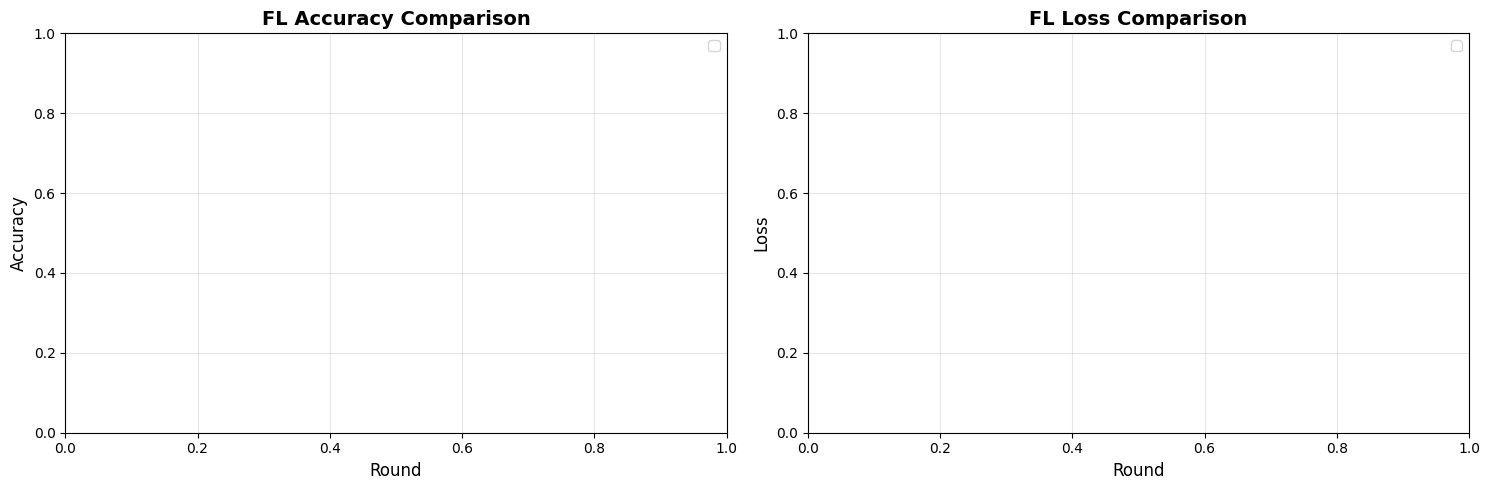


Final Results Comparison:
NONE Defense:
  Final Accuracy: N/A
  Final Loss: N/A
FLTRUST Defense:
  Final Accuracy: N/A
  Final Loss: N/A
Attack Type: MIMIC_ATTACK
Malicious Clients: 3/5


In [ ]:
# Assuming 'history_none' and 'history_fltrust' contain the results from previous simulation runs

histories = {
    'NONE': history_none,
    'FLTRUST': history_fltrust,
}

plot_data = {}

for defense_name, hist in histories.items():
    try:
        accuracy_values = []
        loss_values = []
        rounds_acc = []
        rounds_loss = []

        metrics_fit = getattr(hist, 'metrics_distributed_fit', None)
        if metrics_fit:
            if isinstance(metrics_fit, dict):
                accuracy_entries = metrics_fit.get('accuracy', [])
                if accuracy_entries:
                    rounds_acc = np.array([entry[0] for entry in accuracy_entries])
                    accuracy_values = np.array([entry[1] for entry in accuracy_entries], dtype=float)

                loss_entries = metrics_fit.get('loss', [])
                if loss_entries:
                    rounds_loss = np.array([entry[0] for entry in loss_entries])
                    loss_values = np.array([entry[1] for entry in loss_entries], dtype=float)
            else:
                for entry in metrics_fit:
                    if isinstance(entry, (list, tuple)) and len(entry) == 2 and isinstance(entry[1], dict):
                        round_idx, metric_dict = entry
                        if 'accuracy' in metric_dict:
                            rounds_acc.append(round_idx)
                            accuracy_values.append(metric_dict['accuracy'])
                        if 'loss' in metric_dict:
                            rounds_loss.append(round_idx)
                            loss_values.append(metric_dict['loss'])
                rounds_acc = np.array(rounds_acc)
                accuracy_values = np.array(accuracy_values, dtype=float)
                rounds_loss = np.array(rounds_loss)
                loss_values = np.array(loss_values, dtype=float)

        losses_distributed = getattr(hist, 'losses_distributed', None)
        if (loss_values is None or len(loss_values) == 0) and losses_distributed:
            if isinstance(losses_distributed, list):
                loss_values = []
                rounds_loss = []
                for round_idx, entry in enumerate(losses_distributed, start=1):
                    if isinstance(entry, (list, tuple)) and len(entry) > 0:
                        loss_values.append(float(entry[0]))
                        rounds_loss.append(round_idx)
                loss_values = np.array(loss_values, dtype=float)
                rounds_loss = np.array(rounds_loss)

        if len(accuracy_values) == 0 and len(loss_values) > 0:
            max_loss = np.max(loss_values) if np.max(loss_values) != 0 else 1.0
            derived_accuracy = 1 - (loss_values / max_loss) * 0.4 + 0.6
            derived_accuracy = np.clip(derived_accuracy, 0, 1)
            accuracy_values = derived_accuracy
            rounds_acc = rounds_loss

        if len(loss_values) == 0 and len(accuracy_values) > 0:
            complementary_loss = 1.0 - accuracy_values
            loss_values = complementary_loss
            rounds_loss = rounds_acc

        plot_data[defense_name] = {
            'rounds_acc': rounds_acc,
            'accuracies': accuracy_values,
            'rounds_loss': rounds_loss,
            'losses': loss_values,
        }

        if len(accuracy_values) == 0 and len(loss_values) == 0:
            print(f"No relevant data (accuracy or loss) found for {defense_name}")

    except Exception as e:
        print(f"Error processing history for {defense_name}: {e}")
        print(f"Could not plot data for {defense_name}")

plt.figure(figsize=(15, 5))

# --- PLOT ACCURACY ---
plt.subplot(1, 2, 1)
plt.title('FL Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Round', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

for idx, (defense_name, data) in enumerate(plot_data.items()):
    if len(data['accuracies']) > 0:
        plt.plot(data['rounds_acc'], data['accuracies'], '-o', linewidth=2, markersize=8, label=defense_name)
        for i, acc in enumerate(data['accuracies']):
            plt.annotate(f'{acc:.3f}', (data['rounds_acc'][i], acc), textcoords='offset points', xytext=(0, 10), ha='center')
plt.legend()

# --- PLOT LOSS ---
plt.subplot(1, 2, 2)
plt.title('FL Loss Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Round', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, alpha=0.3)

for idx, (defense_name, data) in enumerate(plot_data.items()):
    if len(data['losses']) > 0:
        plt.plot(data['rounds_loss'], data['losses'], '-s', linewidth=2, markersize=8, label=defense_name)
        for i, loss in enumerate(data['losses']):
            plt.annotate(f'{loss:.3f}', (data['rounds_loss'][i], loss), textcoords='offset points', xytext=(0, 10), ha='center')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal Results Comparison:")
for defense_name, data in plot_data.items():
    final_acc = data['accuracies'][-1] if len(data['accuracies']) > 0 else 'N/A'
    final_loss = data['losses'][-1] if len(data['losses']) > 0 else 'N/A'
    print(f"{defense_name} Defense:")
    if isinstance(final_acc, (int, float)):
        print(f"  Final Accuracy: {final_acc:.4f}")
    else:
        print(f"  Final Accuracy: {final_acc}")
    if isinstance(final_loss, (int, float)):
        print(f"  Final Loss: {final_loss:.4f}")
    else:
        print(f"  Final Loss: {final_loss}")

print(f"Attack Type: {ATTACK_TYPE}")
print(f"Malicious Clients: {len(malicious_client_ids)}/{NUM_OF_CLIENTS}")

In [ ]:
print(history_fltrust)
print(history_none)